In [ ]:
#data loading

import pandas as pd

orders = pd.read_csv("../data/olist_orders_dataset.csv")
items = pd.read_csv("../data/olist_order_items_dataset.csv")

In [ ]:
#data merge
df = pd.merge(orders, items, on="order_id")


In [ ]:
#Feature Engineering
df["total_price"] = df["price"] + df["freight_value"]

In [ ]:
#Analysis
df["total_price"].sum()

np.float64(15843553.239999998)

In [10]:
df.groupby("product_id")["total_price"].sum().sort_values(ascending=False).head(10)

product_id
bb50f2e236e5eea0100680137654686c    67606.10
d1c427060a0f73f6b889a5c7c61f2ac4    60976.03
6cdd53843498f92890544667809f1595    59093.99
99a4788cb24856965c36a24e339b6058    51071.60
d6160fb7873f184099d9bc95e30376af    50326.18
3dd2a17168ec895c781a9191c1e95ad7    48212.22
aca2eb7d00ea1a7b8ebd4e68314663af    44820.76
5f504b3a1c75b73d6151be81eb05bdc9    41725.81
25c38557cf793876c5abdd5931f922db    40311.95
53b36df67ebb7c41585e8d54d6772e08    39957.93
Name: total_price, dtype: float64

<Axes: xlabel='order_purchase_timestamp'>

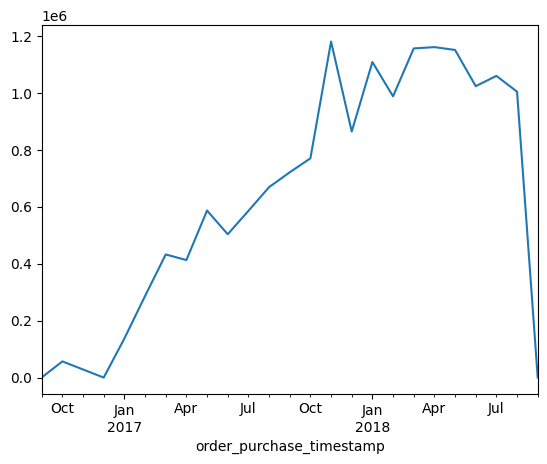

In [12]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

monthly_sales = df.groupby(df["order_purchase_timestamp"].dt.to_period("M"))["total_price"].sum()

monthly_sales.plot()

In [13]:
import plotly.express as px

monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df["order_purchase_timestamp"] = monthly_sales_df["order_purchase_timestamp"].astype(str)

fig = px.line(
    monthly_sales_df,
    x="order_purchase_timestamp",
    y="total_price",
    title="Aylık Satış Trendi"
)

fig.show()

In [14]:
fig.update_layout(
    xaxis_title="Tarih",
    yaxis_title="Gelir",
    title_x=0.5
)

In [17]:
total_revenue = df["total_price"].sum()
total_revenue

np.float64(15843553.239999998)

In [18]:
total_orders = df["order_id"].nunique()
total_orders

98666

In [19]:
avg_order_value = total_revenue / total_orders
avg_order_value

np.float64(160.57763809214924)

In [20]:
top_products = df.groupby("product_id")["total_price"].sum().sort_values(ascending=False).head(10)

top_products

product_id
bb50f2e236e5eea0100680137654686c    67606.10
d1c427060a0f73f6b889a5c7c61f2ac4    60976.03
6cdd53843498f92890544667809f1595    59093.99
99a4788cb24856965c36a24e339b6058    51071.60
d6160fb7873f184099d9bc95e30376af    50326.18
3dd2a17168ec895c781a9191c1e95ad7    48212.22
aca2eb7d00ea1a7b8ebd4e68314663af    44820.76
5f504b3a1c75b73d6151be81eb05bdc9    41725.81
25c38557cf793876c5abdd5931f922db    40311.95
53b36df67ebb7c41585e8d54d6772e08    39957.93
Name: total_price, dtype: float64